In [38]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("tundesta18/sales-forecast-dataset")
df=dataset['train'].to_pandas()
df.columns=df.columns.str.lower()

Repo card metadata block was not found. Setting CardData to empty.


### MRP VS Sales

In [39]:
# Does High MRP Products Generates the highest Sales?
mrp_sales=df.groupby('product_mrp')['product_store_sales_total'].agg(['sum'])
mrp_sales=mrp_sales.sort_values(by='sum',ascending=False).head(12)
mrp_sales

,sum
product_mrp,
160.78,21472.82
153.55,19217.16
157.43,18558.43
156.09,18404.16
138.77,18062.95
166.25,17576.70
144.32,17237.54
142.68,16779.52
142.14,16224.40


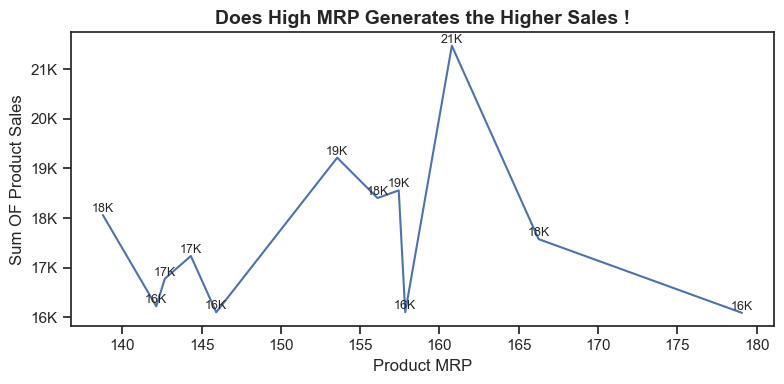

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
fig,ax=plt.subplots(1,1,figsize=(8,4))
sns.set_theme(style='whitegrid')
sns.lineplot(data=mrp_sales,x=mrp_sales.index,y='sum',legend=False)
plt.title('Does High MRP Generates the Higher Sales !',fontsize=14,fontweight='bold')
plt.xlabel('Product MRP',fontsize=12)
plt.ylabel('Sum OF Product Sales',fontsize=12)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x,pos:f'{x/1000:.0f}K')
)
for x, y in zip(mrp_sales.index, mrp_sales["sum"]):
    ax.text(
        x,
        y,
        f"{y/1000:.0f}K",
        ha="center",
        va="bottom",
        fontsize=9
    )
marker="o"
plt.tight_layout()
plt.show()

### Store Age VS Sales

In [41]:
current_year=2026
df['store_age']=current_year - df['store_establishment_year']


In [60]:
store_age_sales=df.groupby('store_age',as_index=False)['product_store_sales_total'].agg('sum')
store_age_sales=store_age_sales.sort_values(by='product_store_sales_total')
store_age_sales

,store_age,product_store_sales_total
1,28.0,2030909.72
2,39.0,6223113.18
0,17.0,15427583.43


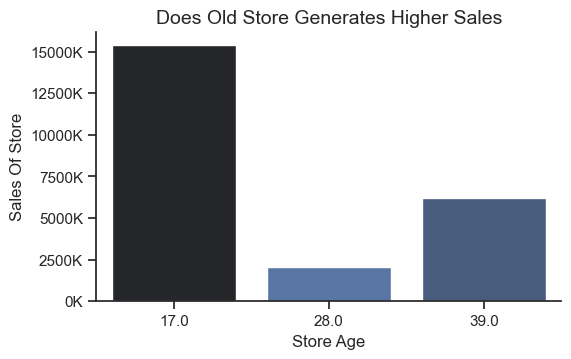

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

fig,ax=plt.subplots(1,1,figsize=(6,3.5))
sns.set_theme(style='ticks')
sns.barplot(data=store_age_sales,x='store_age',y='product_store_sales_total',hue='product_store_sales_total',palette='dark:b_r',legend=False,ax=ax)
sns.despine()
ax.set_title('Does Old Store Generates Higher Sales',fontsize=14)
ax.set_xlabel('Store Age',fontsize=12)
ax.set_ylabel('Sales Of Store',fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter
                             (lambda x,pos:f'{x/1000:.0f}K'))

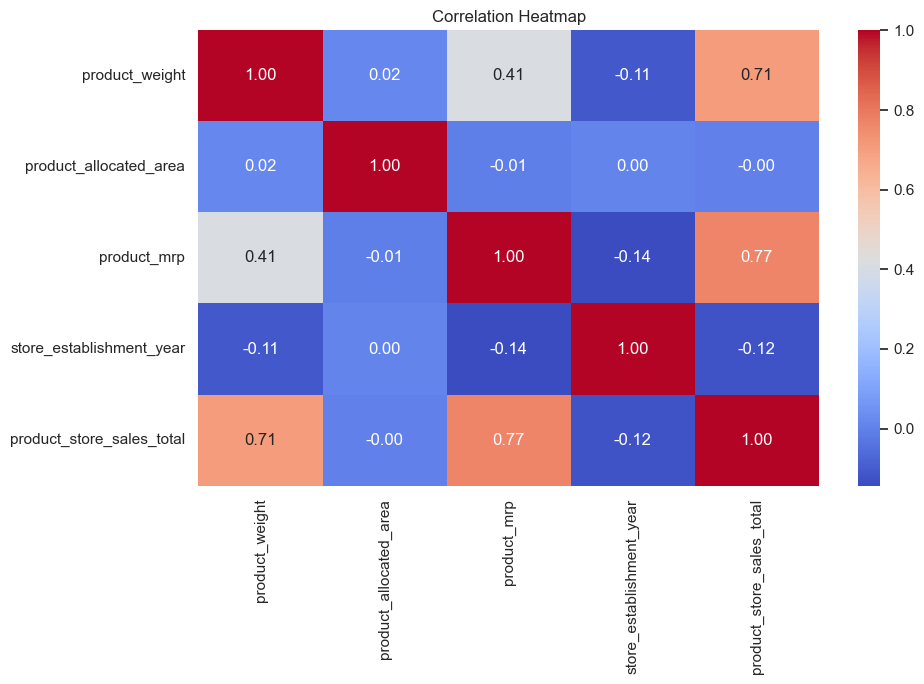

In [ ]:
numeric_columns = [

   "product_weight",
    "product_allocated_area",
    "product_mrp",
    "store_establishment_year",
    "product_store_sales_total"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()